## PIP install necessary imports

In [ ]:
!pip install simpleitk monai segmentation-models-pytorch tqdm


## Importing essential libraries, packages, frameworks

In [ ]:
import os
import glob
import shutil
import time
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from google.colab import drive


import segmentation_models_pytorch as smp
from monai.transforms import (Compose, EnsureChannelFirstd, RandRotate90d, RandFlipd, RandGaussianNoised, RandAdjustContrastd, ToTensord, Resized, RandGridDistortiond)
from monai.losses import DiceFocalLoss
from monai.utils import set_determinism


set_determinism(seed=33)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


## Mounting Google Drive

In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Defining necessary directories

In [4]:
ZIP_FILENAME = "preprocessed_v2.zip"
ZIP_PATH = os.path.join("/content/drive/MyDrive", ZIP_FILENAME)
LOCAL_DATA_DIR = "/content/data_v2"
SAVE_DIR = "/content/drive/MyDrive/models"

os.makedirs(SAVE_DIR, exist_ok=True)

## Defining constants

In [5]:
BATCH_SIZE = 8
LEARNING_RATE = 5e-5
NUM_EPOCHS = 15
TARGET_SIZE = (256, 256)

## Copying ZIP file with preprocessed data from Drive

In order to handle training MUCH faster.

In [6]:
def prepare_data():
    """Function to copy ZIP file from Google Drive with preprocessed data and unzip them to Colab local disk."""

    target_path = os.path.join(LOCAL_DATA_DIR, "preprocessed_v2")

    if os.path.exists(LOCAL_DATA_DIR):
        num_files = len(glob.glob(os.path.join(LOCAL_DATA_DIR, "**", "*.npy"), recursive=True))

        if num_files > 100:
            print(f"Files are ready in {LOCAL_DATA_DIR} ({num_files} files).")

            return target_path

    if not os.path.exists(ZIP_PATH):
        print(f"ERROR: there is no '{ZIP_FILENAME}'on Google Drive.")
        raise FileNotFoundError("No ZIP file.")

    print(f"Starting data loading...")
    start_time = time.time()

    print("Copying ZIP from Drive...")
    shutil.copy(ZIP_PATH, "/content/dataset.zip")

    print("Unzipping.")
    !unzip -q -o /content/dataset.zip -d {LOCAL_DATA_DIR}

    elapsed = time.time() - start_time
    print(f"READY! Data loaded in {elapsed:.1f} seconds.")

    if os.path.exists(target_path):
        return target_path
    else:
        raise FileNotFoundError(f"Folder 'preprocessed_v2' not found inside {LOCAL_DATA_DIR}!")

## Dataloader

Dataset

In [7]:
class SpineDataset(Dataset):

    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        mask_path = img_path.replace('images', 'masks')

        try:
            img_arr = np.load(img_path).astype(np.float32) # data normalized during preprocessing
            mask_arr = np.load(mask_path).astype(np.uint8)

        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            return torch.zeros(1, *TARGET_SIZE), torch.zeros(*TARGET_SIZE).long() # returning empty tensors on error


        # mask binarization
        mask_arr[mask_arr > 0] = 1

        data = {"image": img_arr, "label": mask_arr}

        if self.transform:
            data = self.transform(data)

        image = data["image"]
        mask = data["label"]

        mask = mask.long()

        return image, mask


Transforms

In [8]:
def get_transforms(mode="train"): # TRAINING TRANSFORMS (AUGMENTATIONS)

    if mode == "train":
        return Compose([
            # we make sure that we have [channels (C), height (H), width (W)]
            EnsureChannelFirstd(keys=["image", "label"], channel_dim='no_channel'),
            Resized(keys=["image", "label"], spatial_size=TARGET_SIZE, mode=("bilinear", "nearest")),

            RandAdjustContrastd(keys=["image"], prob=0.5, gamma=(0.5, 2.5)),
            RandGaussianNoised(keys=["image"], prob=0.3, mean=0.0, std=0.1),

            RandRotate90d(keys=["image", "label"], prob=0.5, spatial_axes=[0, 1]),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),

            ToTensord(keys=["image", "label"]),
        ])
    else:
        return Compose([ # VALIDATION AND TEST TRANSFORMS (NO AUGMENTATIONS!!!)
            EnsureChannelFirstd(keys=["image", "label"], channel_dim='no_channel'),
            Resized(keys=["image", "label"], spatial_size=TARGET_SIZE, mode=("bilinear", "nearest")),
            ToTensord(keys=["image", "label"]),
        ])


In [9]:
def get_dataloaders(data_dir, batch_size, val_split=0.2, test_split=0.1):
    search_path = os.path.join(data_dir, "**", "images", "*.npy")
    all_files = glob.glob(search_path, recursive=True)

    if len(all_files) == 0:
        raise ValueError(f"Pusto w {data_dir}. Sprawdź ścieżkę!")

    patient_files = {}
    for f in all_files:
        filename = os.path.basename(f)

        if "Spider" in filename:
            patient_id = filename.split("_slice")[0]
        elif "OSF" in filename:

            parts = filename.split("_")
            patient_id = "_".join(parts[:2])
        elif "SpineOut" in filename:
            patient_id = filename.split("_slice")[0]
        else:
            patient_id = filename.split("_slice")[0]

        if patient_id not in patient_files: patient_files[patient_id] = []
        patient_files[patient_id].append(f)

    patient_ids = list(patient_files.keys())
    train_ids, test_ids = train_test_split(patient_ids, test_size=test_split, random_state=42)
    train_ids, val_ids = train_test_split(train_ids, test_size=val_split, random_state=42)


    def flatten(ids):
        out = []
        for pid in ids: out.extend(patient_files[pid])
        return out

    train_files = flatten(train_ids)
    val_files = flatten(val_ids)

    print(f"Patients: training = {len(train_ids)}, validation = {len(val_ids)}")
    print(f"Slices: training = {len(train_files)}, validation = {len(val_files)}")

    # dtaset
    train_ds = SpineDataset(train_files, transform=get_transforms("train"))
    val_ds = SpineDataset(val_files, transform=get_transforms("val"))

    # dataloader
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    return train_loader, val_loader

## Training + helper functions

In [ ]:
def calculate_metrics(preds, targets):
    """
   Function to calculate Dice score and accuracy for class 1 (spine).
    """

    smooth = 1e-6

    preds_flat = preds.view(-1).float()
    targets_flat = targets.view(-1).float()

    # dice
    intersection = (preds_flat * targets_flat).sum()
    dice = (2. * intersection + smooth) / (preds_flat.sum() + targets_flat.sum() + smooth)

    # accuracy
    correct_pixels = (preds_flat == targets_flat).sum()
    total_pixels = len(targets_flat)
    accuracy = correct_pixels / total_pixels

    return dice, accuracy



def train_one_epoch(model, loader, optimizer, loss_fn, device):

    model.train()
    epoch_loss = 0
    epoch_dice = 0
    epoch_acc = 0

    loop = tqdm(loader, desc="Train", leave=False)

    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)

        # formatting masks to loss [B, 1, H, W]
        if masks.ndim == 3:
            masks_for_loss = masks.unsqueeze(1)
        else:
            masks_for_loss = masks
            masks = masks.squeeze(1)

        # forward
        outputs = model(images)
        loss = loss_fn(outputs, masks_for_loss)

        # backward
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # metrics
        preds = torch.argmax(outputs, dim=1) # [B, H, W]
        dice, acc = calculate_metrics(preds, masks)

        epoch_loss += loss.item()
        epoch_dice += dice.item()
        epoch_acc += acc.item()

        loop.set_postfix(loss=loss.item(), dice=dice.item(), acc=acc.item())

    return epoch_loss / len(loader), epoch_dice / len(loader), epoch_acc / len(loader)



def validate(model, loader, loss_fn, device):

    model.eval()
    val_loss = 0
    val_dice = 0
    val_acc = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            if masks.ndim == 3:
                masks_for_loss = masks.unsqueeze(1)
            else:
                masks_for_loss = masks
                masks = masks.squeeze(1)

            outputs = model(images)
            loss = loss_fn(outputs, masks_for_loss)

            preds = torch.argmax(outputs, dim=1)
            dice, acc = calculate_metrics(preds, masks)

            val_loss += loss.item()
            val_dice += dice.item()
            val_acc += acc.item()

    return val_loss / len(loader), val_dice / len(loader), val_acc / len(loader)


## Main workflow

In [11]:
def visualize_prediction(model, loader, device):
    """Function showing one validation example image for us to see what is going on."""
    model.eval()
    images, masks = next(iter(loader))
    images, masks = images.to(device), masks.to(device)

    with torch.no_grad():
        outputs = model(images)
        preds = (torch.sigmoid(outputs[:, 1, ...]) > 0.5).float() # class 1 (spine)

    # taking first img from batch
    img = images[0, 0].cpu().numpy()
    msk = masks[0].cpu().numpy().squeeze(0)
    prd = preds[0].cpu().numpy()

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(img, cmap='gray'); plt.title("MRI")
    plt.subplot(1, 3, 2); plt.imshow(msk, cmap='gray'); plt.title("Ground truth")
    plt.subplot(1, 3, 3); plt.imshow(prd, cmap='gray'); plt.title("Model prediction")

    plt.show()


def main_train():
    print(f"Training on: {DEVICE}")


    data_path = prepare_data()
    print("Dataloader creating...")
    train_loader, val_loader = get_dataloaders(data_path, batch_size=16)

    print("Bulding Unet++ model with encoder: ResNet34...")

    model = smp.UnetPlusPlus(
        encoder_name='resnet34',
        encoder_weights="imagenet",
        in_channels=1,
        classes=2,
        decoder_attention_type='scse'
    ).to(DEVICE)


    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

    loss_fn = DiceFocalLoss(softmax=True, to_onehot_y=True, lambda_dice=1.0, lambda_focal=2.0)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)



    best_val_dice = 0.0

    print(f"\nTraining starting: {NUM_EPOCHS} epochs.")


    for epoch in range(NUM_EPOCHS):
        print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")

        t_loss, t_dice, t_acc = train_one_epoch(model, train_loader, optimizer, loss_fn, DEVICE)
        v_loss, v_dice, v_acc = validate(model, val_loader, loss_fn, DEVICE)

        scheduler.step(v_loss)
        lr = optimizer.param_groups[0]['lr']

        print(f"Loss -- training: {t_loss:.4f} | validation: {v_loss:.4f}")
        print(f"Dice -- training: {t_dice:.3f} | validation: {v_dice:.3f}")
        print(f"Learning rate: {lr:.2e}")


        visualize_prediction(model, val_loader, DEVICE)

        if v_dice > best_val_dice:
            best_val_dice = v_dice
            torch.save(model.state_dict(), os.path.join(SAVE_DIR, "best_model.pth"))
            print(f"New record! Dice: {v_dice:.3f}")

Training on: cuda
Files are ready in /content/data_v2 (59348 files).
Dataloader creating...
Patients: training = 312, validation = 78
Slices: training = 21382, validation = 5341
Bulding Unet++ model with encoder: ResNet34...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(



Training starting: 15 epochs.

--- Epoch 1/15 ---


Loss -- training: 0.2175 | validation: 0.3098
Dice -- training: 0.862 | validation: 0.752
Learning rate: 1.00e-04


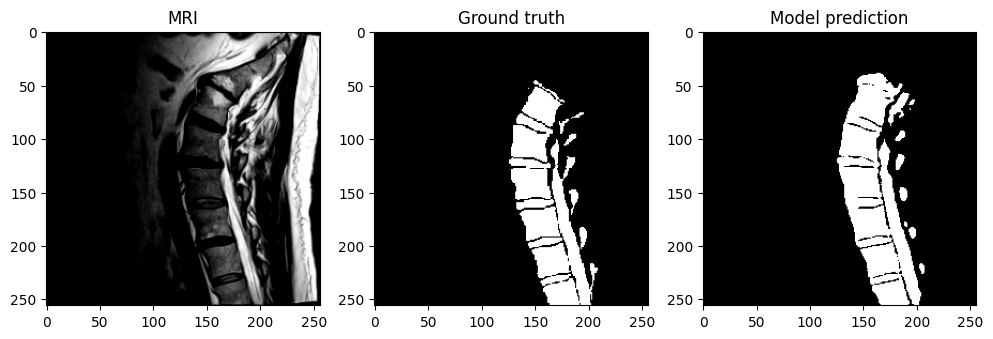

New record! Dice: 0.752

--- Epoch 2/15 ---


Loss -- training: 0.1106 | validation: 0.3323
Dice -- training: 0.908 | validation: 0.743
Learning rate: 1.00e-04


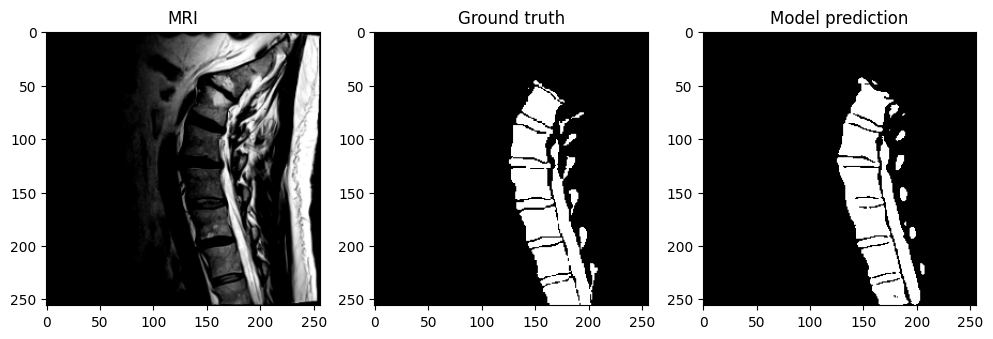


--- Epoch 3/15 ---


Loss -- training: 0.0982 | validation: 0.3087
Dice -- training: 0.916 | validation: 0.760
Learning rate: 1.00e-04


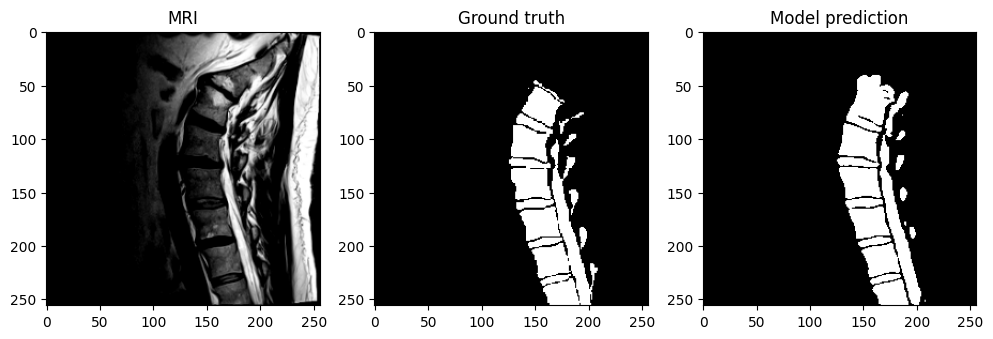

New record! Dice: 0.760

--- Epoch 4/15 ---


Loss -- training: 0.0900 | validation: 0.3566
Dice -- training: 0.921 | validation: 0.726
Learning rate: 1.00e-04


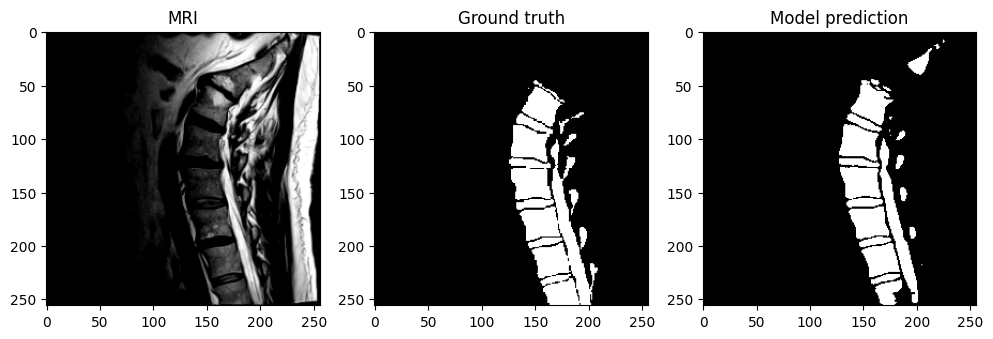


--- Epoch 5/15 ---


Loss -- training: 0.0835 | validation: 0.3664
Dice -- training: 0.925 | validation: 0.738
Learning rate: 1.00e-04


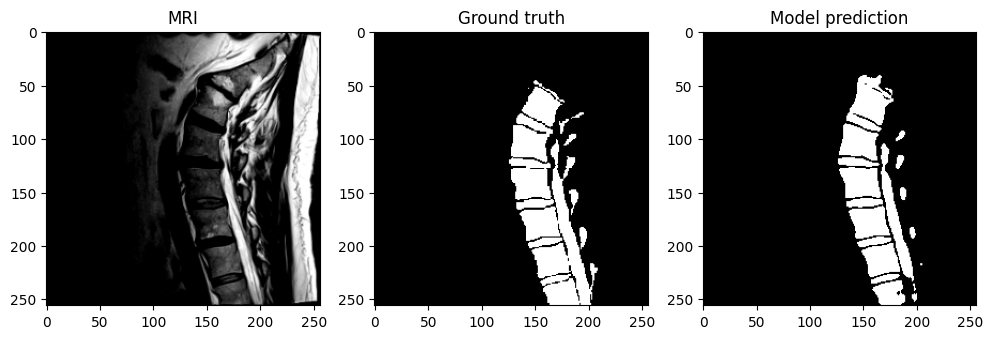


--- Epoch 6/15 ---


Loss -- training: 0.0786 | validation: 0.3712
Dice -- training: 0.929 | validation: 0.731
Learning rate: 1.00e-04


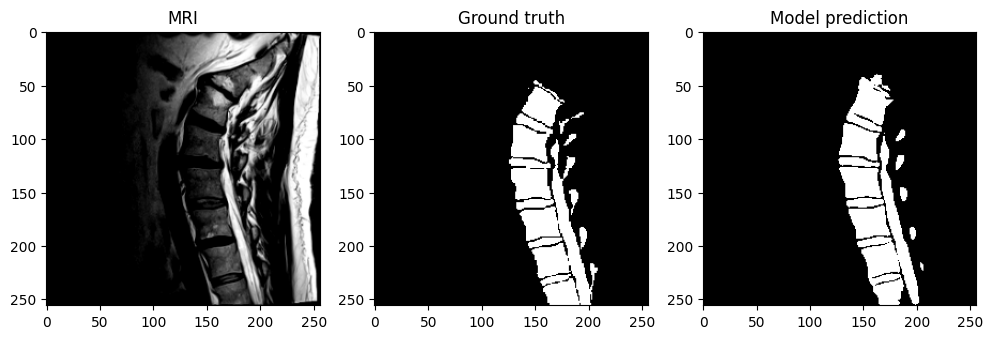


--- Epoch 7/15 ---


Loss -- training: 0.0742 | validation: 0.3860
Dice -- training: 0.932 | validation: 0.732
Learning rate: 5.00e-05


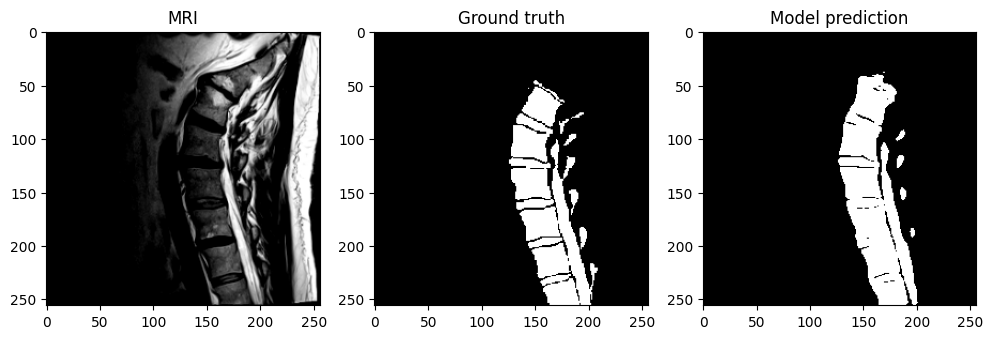


--- Epoch 8/15 ---


Loss -- training: 0.0657 | validation: 0.3727
Dice -- training: 0.938 | validation: 0.747
Learning rate: 5.00e-05


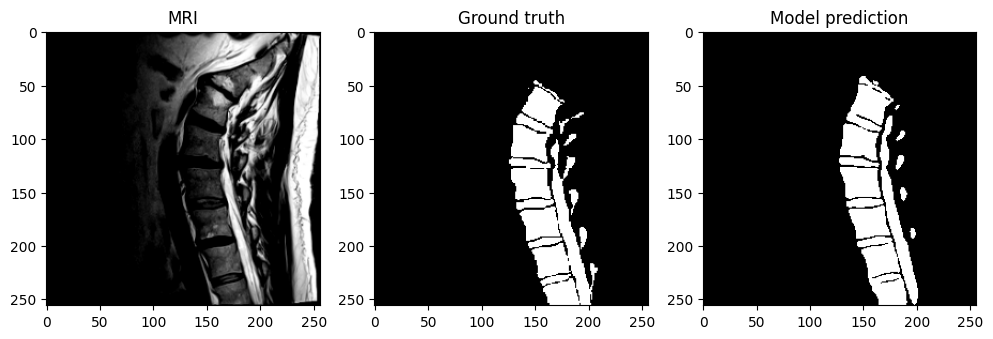


--- Epoch 9/15 ---


Loss -- training: 0.0612 | validation: 0.4123
Dice -- training: 0.941 | validation: 0.729
Learning rate: 5.00e-05


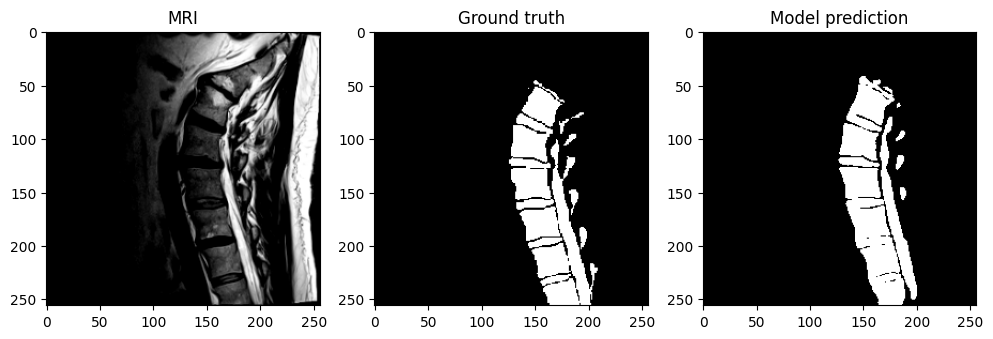


--- Epoch 10/15 ---


Loss -- training: 0.0582 | validation: 0.4082
Dice -- training: 0.944 | validation: 0.735
Learning rate: 5.00e-05


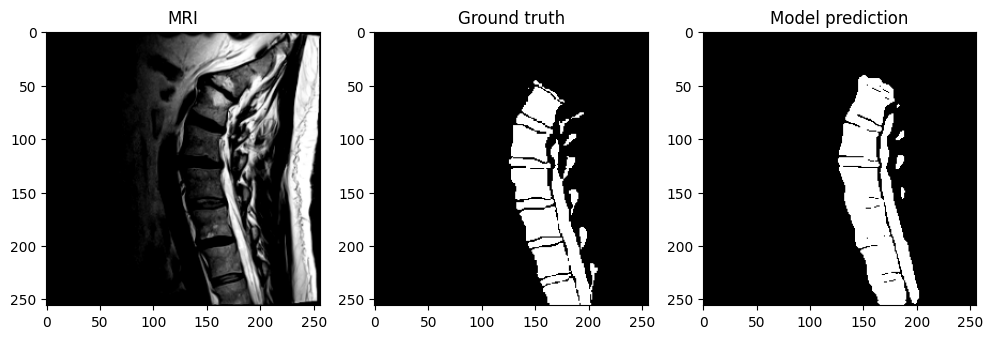


--- Epoch 11/15 ---


Loss -- training: 0.0553 | validation: 0.4189
Dice -- training: 0.946 | validation: 0.731
Learning rate: 2.50e-05


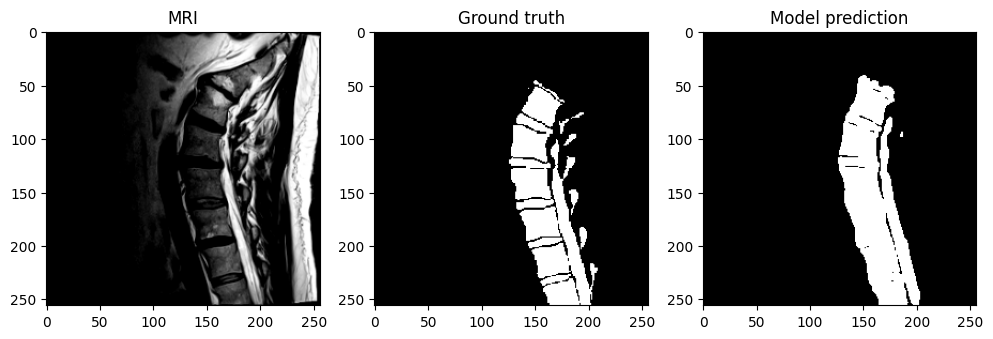


--- Epoch 12/15 ---


Loss -- training: 0.0509 | validation: 0.4133
Dice -- training: 0.950 | validation: 0.739
Learning rate: 2.50e-05


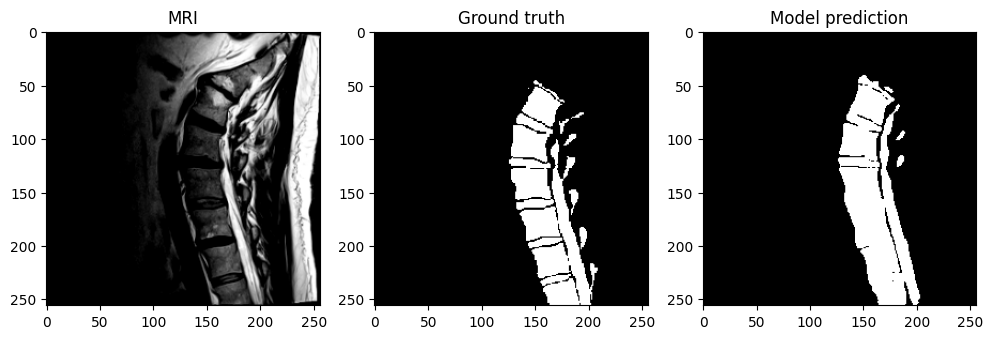


--- Epoch 13/15 ---


Loss -- training: 0.0484 | validation: 0.4239
Dice -- training: 0.951 | validation: 0.736
Learning rate: 2.50e-05


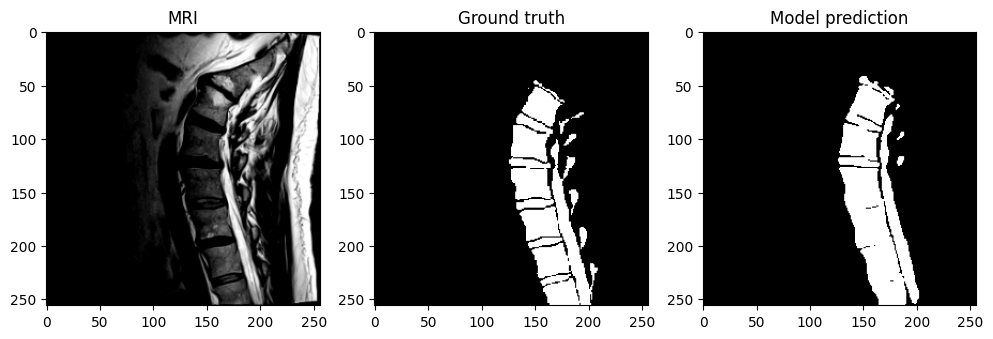


--- Epoch 14/15 ---


Loss -- training: 0.0467 | validation: 0.4343
Dice -- training: 0.953 | validation: 0.735
Learning rate: 2.50e-05


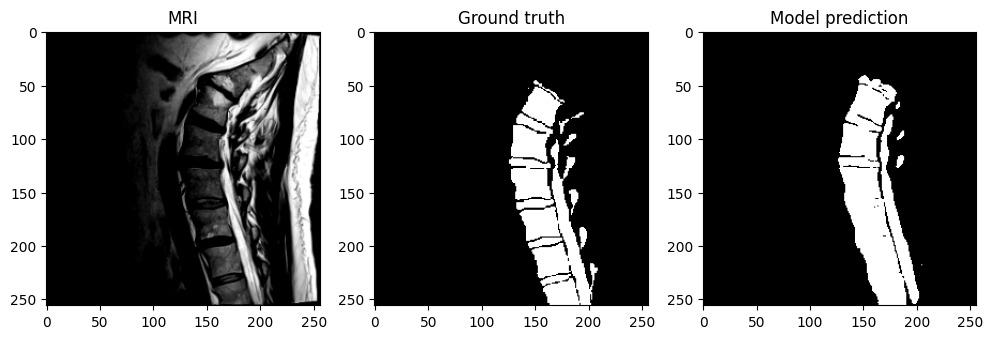


--- Epoch 15/15 ---


Loss -- training: 0.0453 | validation: 0.4291
Dice -- training: 0.954 | validation: 0.736
Learning rate: 1.25e-05


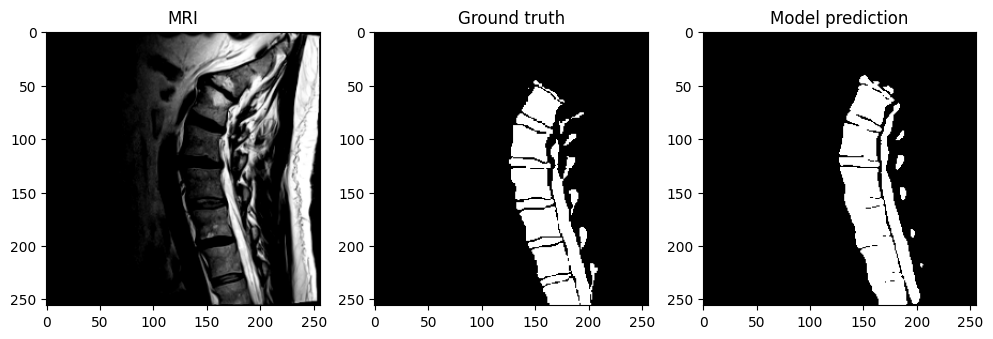

In [12]:
if __name__ == "__main__":
    main_train()